# Benchmarking Performance Test

## Fibonacci dan CCTV Classification

## Fibonacci - Loop vs Cache

In [23]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from functools import lru_cache
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [24]:
def fib_loop(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n + 1):
        a, b = b, a + b
    return b

@lru_cache(maxsize=None)
def fib_cache(n):
    if n <= 1:
        return n
    return fib_cache(n - 1) + fib_cache(n - 2)

print(f"loop: {fib_loop(10)}, cache: {fib_cache(10)}")

loop: 55, cache: 55


In [25]:
test_values = [20, 100, 1000]
results = {'n': [], 'loop_time': [], 'cache_time': [], 'speedup': [], 'result': []}

for n in test_values:
    fib_cache.cache_clear()
    
    t1 = time.time()
    r1 = fib_loop(n)
    t_loop = time.time() - t1
    
    t1 = time.time()
    r2 = fib_cache(n)
    t_cache = time.time() - t1
    
    speedup = t_loop / t_cache if t_cache > 0 else 0
    
    results['n'].append(n)
    results['loop_time'].append(t_loop)
    results['cache_time'].append(t_cache)
    results['speedup'].append(speedup)
    results['result'].append(r1)
    
    print(f"n={n}: loop={t_loop:.6f}s, cache={t_cache:.6f}s, speedup={speedup:.2f}x")

df_fib = pd.DataFrame(results)
print(df_fib)

n=20: loop=0.000000s, cache=0.000000s, speedup=0.00x
n=100: loop=0.000000s, cache=0.000000s, speedup=0.00x
n=1000: loop=0.000000s, cache=0.007805s, speedup=0.00x
      n  loop_time  cache_time  speedup  \
0    20        0.0    0.000000      0.0   
1   100        0.0    0.000000      0.0   
2  1000        0.0    0.007805      0.0   

                                              result  
0                                               6765  
1                              354224848179261915075  
2  4346655768693745643568852767504062580256466051...  


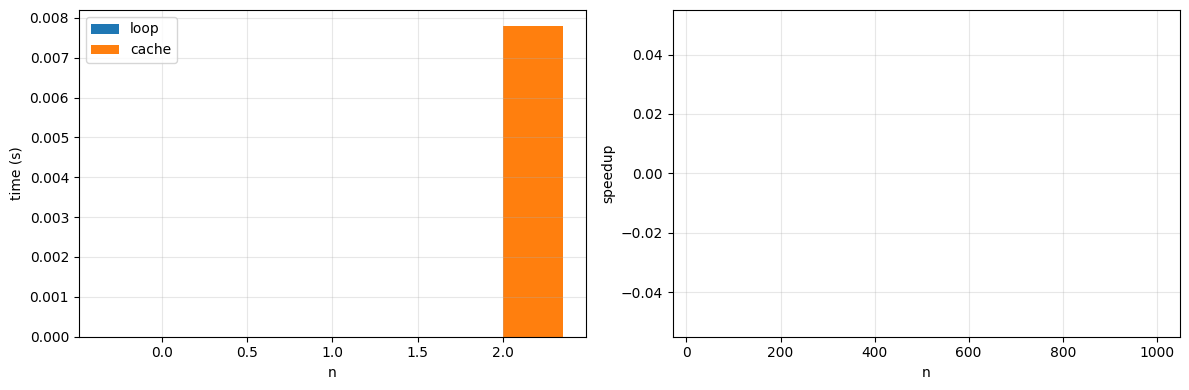

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

x = np.arange(len(df_fib))
width = 0.35

ax1.bar(x - width/2, df_fib['loop_time'], width, label='loop')
ax1.bar(x + width/2, df_fib['cache_time'], width, label='cache')
ax1.set_ylabel('time (s)')
ax1.set_xlabel('n')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.bar(df_fib['n'], df_fib['speedup'])
ax2.set_ylabel('speedup')
ax2.set_xlabel('n')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fib_bench.png')
plt.show()

## CCTV Classification

Random Forest vs SVM

In [27]:
# Generate Synthetic CCTV Dataset
from sklearn.datasets import make_classification

if use_real_data:
    print("Loading real dataset...")
    # Add code here to load real dataset from ./data/cctv/
    # For now, fallback to synthetic
    pass

if not use_real_data:
    print("Generating synthetic CCTV dataset...")
    X, y = make_classification(
        n_samples=2000,
        n_features=50,
        n_informative=30,
        n_redundant=10,
        n_classes=2,
        random_state=42,
        shuffle=True
    )

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Split: train={X_train_scaled.shape[0]}, test={X_test_scaled.shape[0]}")

Generating synthetic CCTV dataset...
Dataset: 2000 samples, 50 features
Split: train=1400, test=600


In [28]:
import os
from pathlib import Path

dataset_path = Path('./data/cctv')
use_real_data = False

if dataset_path.exists():
    files = list(dataset_path.glob('**/*'))
    if len(files) > 0:
        use_real_data = True
        print(f"Dataset found: {len(files)} files")
        print(f"Path: {dataset_path}")

if not use_real_data:
    print("Using synthetic dataset for benchmarking")
    print("Dataset location for real data: ./data/cctv/")

Using synthetic dataset for benchmarking
Dataset location for real data: ./data/cctv/


In [29]:
# CCTV Classification Benchmarking
print("=" * 80)
print("CCTV CLASSIFICATION BENCHMARKING: Random Forest vs SVM")
print("=" * 80)

# Dictionary untuk menyimpan hasil
results_cctv = {
    'Algorithm': [],
    'Training_Time(s)': [],
    'Prediction_Time(s)': [],
    'Total_Time(s)': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1_Score': []
}

# ========== ALGORITHM 1: RANDOM FOREST ==========
print("\nRandom Forest")

start_train = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rf_model.fit(X_train_scaled, y_train)
time_train_rf = time.time() - start_train

start_pred = time.time()
y_pred_rf = rf_model.predict(X_test_scaled)
time_pred_rf = time.time() - start_pred

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print(f"train: {time_train_rf:.4f}s, pred: {time_pred_rf:.4f}s")
print(f"acc: {acc_rf:.4f}, prec: {prec_rf:.4f}, rec: {rec_rf:.4f}, f1: {f1_rf:.4f}")

results_cctv['Algorithm'].append('RF')
results_cctv['Training_Time(s)'].append(time_train_rf)
results_cctv['Prediction_Time(s)'].append(time_pred_rf)
results_cctv['Total_Time(s)'].append(time_train_rf + time_pred_rf)
results_cctv['Accuracy'].append(acc_rf)
results_cctv['Precision'].append(prec_rf)
results_cctv['Recall'].append(rec_rf)
results_cctv['F1_Score'].append(f1_rf)

# ========== ALGORITHM 2: SUPPORT VECTOR MACHINE (SVM) ==========
print("\nSVM")

start_train = time.time()
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    verbose=0
)
svm_model.fit(X_train_scaled, y_train)
time_train_svm = time.time() - start_train

start_pred = time.time()
y_pred_svm = svm_model.predict(X_test_scaled)
time_pred_svm = time.time() - start_pred

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, zero_division=0)

print(f"train: {time_train_svm:.4f}s, pred: {time_pred_svm:.4f}s")
print(f"acc: {acc_svm:.4f}, prec: {prec_svm:.4f}, rec: {rec_svm:.4f}, f1: {f1_svm:.4f}")

results_cctv['Algorithm'].append('SVM')
results_cctv['Training_Time(s)'].append(time_train_svm)
results_cctv['Prediction_Time(s)'].append(time_pred_svm)
results_cctv['Total_Time(s)'].append(time_train_svm + time_pred_svm)
results_cctv['Accuracy'].append(acc_svm)
results_cctv['Precision'].append(prec_svm)
results_cctv['Recall'].append(rec_svm)
results_cctv['F1_Score'].append(f1_svm)

df_cctv = pd.DataFrame(results_cctv)
print(df_cctv)

CCTV CLASSIFICATION BENCHMARKING: Random Forest vs SVM

Random Forest
train: 0.4568s, pred: 0.0470s
acc: 0.8583, prec: 0.8664, rec: 0.8462, f1: 0.8562

SVM
train: 0.1366s, pred: 0.1005s
acc: 0.9433, prec: 0.9492, rec: 0.9365, f1: 0.9428
  Algorithm  Training_Time(s)  Prediction_Time(s)  Total_Time(s)  Accuracy  \
0        RF          0.456754            0.047023       0.503776  0.858333   
1       SVM          0.136609            0.100462       0.237071  0.943333   

   Precision    Recall  F1_Score  
0   0.866438  0.846154  0.856176  
1   0.949153  0.936455  0.942761  


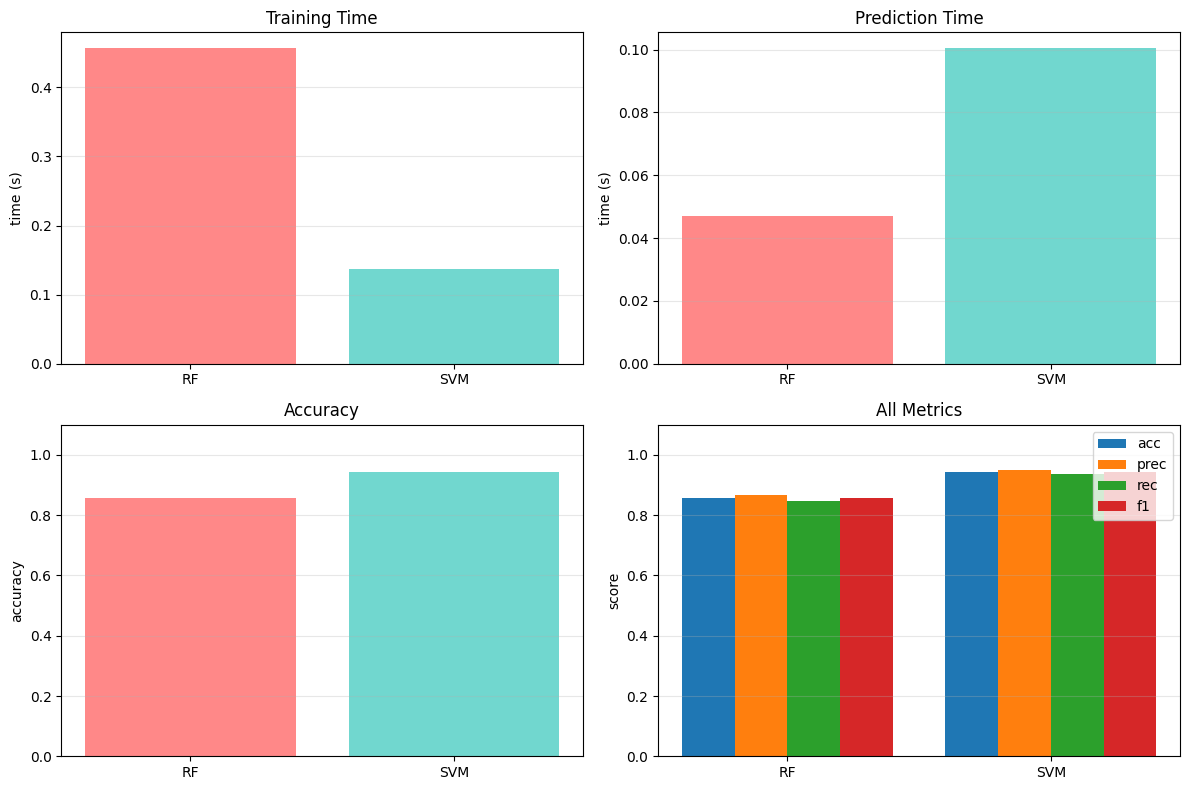

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4']

ax = axes[0, 0]
bars = ax.bar(df_cctv['Algorithm'], df_cctv['Training_Time(s)'], color=colors, alpha=0.8)
ax.set_ylabel('time (s)')
ax.set_title('Training Time')
ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
bars = ax.bar(df_cctv['Algorithm'], df_cctv['Prediction_Time(s)'], color=colors, alpha=0.8)
ax.set_ylabel('time (s)')
ax.set_title('Prediction Time')
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 0]
bars = ax.bar(df_cctv['Algorithm'], df_cctv['Accuracy'], color=colors, alpha=0.8)
ax.set_ylabel('accuracy')
ax.set_title('Accuracy')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
x = np.arange(len(df_cctv))
width = 0.2
ax.bar(x - 1.5*width, df_cctv['Accuracy'], width, label='acc')
ax.bar(x - 0.5*width, df_cctv['Precision'], width, label='prec')
ax.bar(x + 0.5*width, df_cctv['Recall'], width, label='rec')
ax.bar(x + 1.5*width, df_cctv['F1_Score'], width, label='f1')
ax.set_ylabel('score')
ax.set_title('All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(df_cctv['Algorithm'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cctv_bench.png')
plt.show()

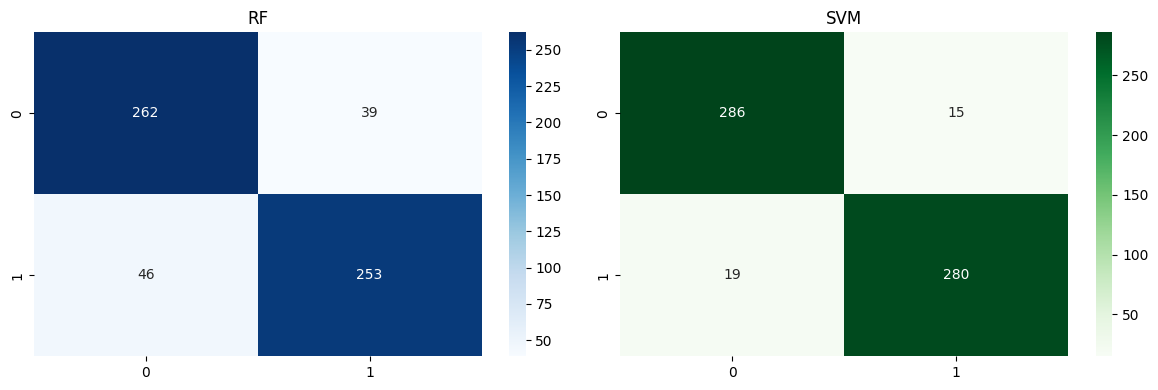

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('RF')

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('SVM')

plt.tight_layout()
plt.savefig('cctv_confusion.png')
plt.show()

In [32]:
print(f"RF vs SVM")
print(f"RF: train={time_train_rf:.4f}s, acc={acc_rf:.4f}")
print(f"SVM: train={time_train_svm:.4f}s, acc={acc_svm:.4f}")

if acc_svm > acc_rf:
    print(f"SVM lebih bagus")
else:
    print(f"RF lebih bagus")

RF vs SVM
RF: train=0.4568s, acc=0.8583
SVM: train=0.1366s, acc=0.9433
SVM lebih bagus
